## Import and define functions

In [ ]:
import os
import warnings
import random
import pickle
from datetime import datetime
from collections import defaultdict
from functools import partial

# Environment configuration
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=14'

import numpyro
from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood, hmc
from numpyro.infer.util import initialize_model
from numpyro.util import fori_collect

import jax
from jax import config
config.update("jax_enable_x64", True)
config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp
from jax import jit, pmap, devices, device_get, lax, local_device_count, random, vmap, block_until_ready
from jax.random import PRNGKey, split
from jax.scipy.optimize import minimize
from jax.scipy.signal import fftconvolve
from jax.scipy.signal import convolve as jax_convolve

# Check devices
print('Available devices:', devices())
print('CPU devices:', devices('cpu'))

# Suppress warnings
warnings.filterwarnings('ignore', message="It appears that you're using a Mac with one of Apple's ARM-based processors")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, to_hex
import corner

import astropy.units as u
import astropy.constants as c
from astropy.constants import G, m_p
from astropy.table import Table

import shone

import fleck
from fleck.jax import ActiveStar

from scipy.optimize import fmin_powell, curve_fit
from scipy.stats import gaussian_kde


from chromatic import *
from svo_filters import svo
from sphinx import get_interp_stellar_spectrum

import arviz
import arviz as az

from tqdm.auto import tqdm

example_sphinx_file = pd.read_csv('../../../../model-spectra/sphinx/SPECTRA/Teff_2000.0_logg_4.5_logZ_-0.5_CtoO_0.3_spectra.txt',
                             comment='#',delimiter=r'\s+',
                             names=['wavelength', 'flux']
                             )
panchromatic_wavelengths = example_sphinx_file['wavelength'].values
# half_diffs = np.diff(panchromatic_wavelengths) / 2.0
# bin_edges = np.zeros(len(panchromatic_wavelengths) + 1)
# bin_edges[0] = panchromatic_wavelengths[0] - half_diffs[0]
# bin_edges[1:-1] = panchromatic_wavelengths[:-1] + half_diffs
# bin_edges[-1] = panchromatic_wavelengths[-1] + half_diffs[-1]
# panchromatic_bin_edges = bin_edges
panchromatic_sphinx_grid = get_interp_stellar_spectrum(panchromatic_wavelengths)

species = ['H2O', 'CH4', 'CO2', 'CO','NH3']

visits = {
    'F21': {
        'Grism': 'G141',
        # 'Forward': G_141_for_dict,
        # 'Backward': G_141_back_dict,
        'BJD_times': np.array(pd.read_csv('../../data/F21_bjdtimes.csv')['BJD'][:]) * u.day,
        'time_lower': 2459455.708 * u.day,
        'time_upper': 2459455.738 * u.day,
        'T0 (BJD_TDB)': 2459455.9895 * u.day,
        'exp (s)': 4.9784 * u.s,
        'native resolution': 46.3 * u.angstrom
    },
    'S22': {
        'Grism': 'G102',
        # 'Forward': G_102_for_dict,
        # 'Backward': G_102_back_dict,
        'BJD_times': np.array(pd.read_csv('../../data/S22_bjdtimes.csv')['BJD'][:]) * u.day,
        'time_lower': 2459684.215 * u.day,
        'time_upper': 2459684.243 * u.day,
        'T0 (BJD_TDB)': 2459684.4959 * u.day, # This is 27 planetary orbits after the first transit, + 0.0054 days (the transit arrived 7 minutes late)
        'exp (s)': 9.67632 * u.s,
        'native resolution': 24.6 * u.angstrom
    }
}

systeminfo = {
    'duration (hr)': 3.5 * u.hr,
    'T_orb (d)': 8.463 * u.day,
    'T_rot (d)': 4.86 * u.day,
    'inclination': 89.5,
    'eccentricity': 0.0,
    'longitude_of_periastron': 88.4
}

def read_sensitivity_curve(grism='G141'):
    path = f'../../data/WFC3.IR.{grism}.1st.sens.2.fits'

    response = fits.open(path)

    w = response[1].data['wavelength']/1e4 * u.micron
    s = response[1].data['sensitivity'] * u.cm * u.cm / u.erg
    e = response[1].data['error'] * u.cm * u.cm / u.erg
    
    return w, s, e

@jit
def get_planck_spectrum_jax(T, **kwargs):
    """
    Calculate the surface flux from a thermally emitted surface,
    according to Planck function.

    Parameters
    ----------
    wavelength : Quantity
        The wavelengths at which to calculate,
        with units of wavelength.
    temperature : Quantity
        The temperature of the thermal emitter,
        with units of K.

    Returns
    -------
    surface_flux : Quantity
        The surface flux, evaluated at the wavelengths.
    """

    # define variables as shortcut to the constants we need
    h = 6.62607e-27 # erg s
    k = 1.380649e-16 # erg/K
    c = 2.9979e18 # angstrom/s
    wavelength = panchromatic_wavelengths*1e4

    z = h * c / (wavelength * k * T) # units check out

    # calculate the intensity from the Planck function
    intensity = (2 * h * c**2 / wavelength**5 / (jnp.exp(z) - 1)) # Units are erg/s/A^3

    # calculate the flux assuming isotropic emission
    flux = jnp.pi * intensity * 1e16 # erg / (s * cm^2 * angstrom)

    # return the intensity
    wave_jax = jnp.array(panchromatic_wavelengths)
    flux_jax = jnp.array(flux)

    return wave_jax, flux_jax

@jit
def convolve_spectrum_jax(model_wavelength, model_flux, sigma, kernel_size=3, **kwargs):
    """
    Properly convolve a spectrum with a Gaussian kernel in JAX.
    
    Args:
        model_wavelength: Array of wavelengths (must be evenly spaced!)
        model_flux: Corresponding flux values
        sigma: Standard deviation of Gaussian kernel in wavelength units
        kernel_size: Number of elements in the kernel (odd number recommended)
        
    Returns:
        Convolved flux array
    """
    # Ensure inputs are JAX arrays
    model_wavelength = jnp.asarray(model_wavelength)
    model_flux = jnp.asarray(model_flux)
    
    # Create proper Gaussian kernel
    x = jnp.linspace(-(kernel_size//2), kernel_size//2, kernel_size)
    kernel = jnp.exp(-0.5 * (x/sigma)**2)
    kernel = kernel / jnp.sum(kernel)  # normalize
    
    # Perform convolution
    convolved = jax_convolve(model_flux, kernel, mode='same', method='fft')
    
    return convolved

@jit
def get_sphinx_spectrum_jax(T, logg, metallicity, CtoO, grid=panchromatic_sphinx_grid, **kwargs):
    
    # Fix: Create a tuple of the three values, then convert to array
    gridspec = grid(
        jnp.array(T, dtype=jnp.float64),
        jnp.array(logg, dtype=jnp.float64),
        jnp.array(metallicity, dtype=jnp.float64),
        jnp.array(CtoO, dtype=jnp.float64)
    )
    
    # Calculate the normalization factor
    # sigma_sb = 5.67e-5  # erg/cm^2/s
    # nf = (sigma_sb * (T)**4) / (jnp.trapezoid(gridspec, x=jnp.array(panchromatic_wavelengths)*1e4))
    re_normed_flux = gridspec #* nf
    
    wave_jax = jnp.array(panchromatic_wavelengths)
    flux_jax = jnp.array(re_normed_flux)
    
    return wave_jax, flux_jax

F21_SED_err_factor = np.array([11.606,10.016,3.183,2.000,2.718,3.906,6.409,
                               2.0,3.460,3.134,2.821,2.0,2.0,5.550,
                               2.273,2.000,2.000,2.0,5.025,4.385,2.0,
                               2.683,3.160,2.0,3.135,2.128,2.000,2.000,
                               2.0,2.694,3.583,2.0,2.0,3.989,3.019,
                               6.914,17.888,18.138,5.215,8.532,2.183,3.095,
                               2.0,2.0,4.225,5.362,2.000,2.000,2.0,
                               4.008,4.563,7.652,2.144,2.762,3.996,9.622,
                               2.0,2.0,4.172,2.0,2.942,3.088,3.457,
                               2.0,4.303,2.257,4.045,11.133,4.696,2.0,
                               2.0,2.184,2.651,2.481,2.0,3.845,2.0,
                               2.0,8.637,2.695,8.502,2.680,5.431,4.670,
                               2.0,2.0,2.0,2.0,3.382,6.319,2.400,
                               2.0,2.0,2.0,2.878,3.070,10.219,3.012,
                               2.082,7.564,11.554,5.829,2.976,3.876,4.837,
                               7.078,2.0,2.775,2.0,2.000,])


S22_SED_err_factor = ([1.100, 1.100,1.000,1.100,1.100,1.100,
                       1.100,1.100,1.100,1.100,1.187,1.341,1.100,
                       1.100,1.100,1.100,1.012,1.100,1.1,1.283,
                       1.125,1.272,1.362,1.922,1.976,2.007,1.206,
                       1.387,1.357,1.392,1.798,1.202,1.100,1.100,
                       1.1,1.100,1.223,1.100,1.120,1.131,1.100,
                       1.219,1.100,1.100,1.295,1.1,1.1,1.1,
                       1.100,1.100,1.100,1.000,1.1,1.487,1.265,
                       1.1,1.100,1.1,1.364,1.1,1.1,1.1,
                       1.100,1.100,1.069,1.237,1.486,1.222,1.1,
                       1.103,1.100,1.1,1.1,1.268,1.1,1.1,
                       1.1,1.100,1.1,1.223,1.781,1.470,1.1,
                       1.100,1.100,1.185,1.762,2.281,1.247,1.102,
                       1.1,1.482,1.221,1.1,1.118,1.100,1.108,
                       1.134,1.10,1.100,1.100,1.100,1.100,1.100,
                       1.224,1.1,1.1,1.100,1.1,1.1,1.10,
                       1.1,1.1,1.1,1.1,1.1,1.194,1.791,
                       2.815,1.795,1.1,1.321,1.827,1.840,1.222,
                       1.106,1.100,1.1,1.100,1.1,1.1,1.151,
                       1.221,1.100,1.135,1.115,1.100,1.100,])

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13)]


In [ ]:
rng_seed = 0

def hstack_recursive(final_states, checkpoint_states):
    for key in final_states.keys():
        if isinstance(final_states[key], dict):
            hstack_recursive(final_states[key], checkpoint_states[key])
        else:
            final_states[key] = jnp.hstack([
                final_states[key], 
                checkpoint_states[key]
            ])

def print_big_message(big_message):
    print('\n\n')
    print('=' * len(big_message))
    print(big_message)
    print('=' * len(big_message))
    print('\n\n')

def post_batch_viz_save(self, **kwargs):
    """
    here we define some tasks to do after each completed checkpoint:
    """
    print(f'Corner for checkpoint {self.checkpoint}')

    samples_cumulative = self.get_samples()
    corner.corner(samples_cumulative)
    plt.suptitle(f'checkpoint {self.checkpoint}')
    plt.savefig(f'../../figs/jointvisit_chkpt_{self.checkpoint}_SED_corner.png', dpi=200)
    plt.show()
    plt.clf()
    
    # EXTRACT MEDIAN PARAMETERS DIRECTLY FROM SAMPLES (like corner plot does)
    chkpt_median_params = {}
    for param_name, param_samples in samples_cumulative.items():
        # param_samples has shape (num_chains, num_samples)
        # Flatten across chains and compute median
        flattened_samples = param_samples.flatten()
        chkpt_median_params[param_name] = float(jnp.median(flattened_samples))
    
    print("Median parameters from samples:")
    for param, value in chkpt_median_params.items():
        print(f"  {param}: {value:.6f}")
    
    # Calculate and print maximum log likelihood
    if 'log_likelihood' in samples_cumulative:
        log_lik_samples = samples_cumulative['log_likelihood'].flatten()
        max_log_lik = float(jnp.max(log_lik_samples))
        print(f"Maximum log likelihood: {max_log_lik:.6f}")
        
        # Also compute Bayesian Information Criterion (BIC) if you want
        n_params = len([p for p in samples_cumulative.keys() if p != 'log_likelihood'])
        n_data = len(SED_wavelengths_G102) + len(SED_wavelengths_G141)  # number of data points
        bic = -2 * max_log_lik + n_params * jnp.log(n_data)
        print(f"BIC: {bic:.6f}")

    with open(f'../../data/samples/samples_cumulative_{self.start_time}_checkpoint_{self.checkpoint:04d}.pkl', 'wb') as file:
        pickle.dump(dict(samples_cumulative), file)

class MCMCWithCheckpoints(MCMC):
    running_states = None
    checkpoint = 0
    start_time = None
    
    def run_checkpoints(self, rng_key, *args, extra_fields=(), n_checkpoints=10, 
                        progress_bar_warmup=True, progress_bar_samples=True, 
                        init_params=None, on_checkpoint=None, **kwargs):
        """
        Run the MCMC samplers and collect samples.

        :param random.PRNGKey rng_key: Random number generator key to be used for the sampling.
            For multi-chains, a batch of `num_chains` keys can be supplied. If `rng_key`
            does not have batch_size, it will be split in to a batch of `num_chains` keys.
        :param args: Arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init` method.
            These are typically the arguments needed by the `model`.
        :param extra_fields: Extra fields (aside from `"z"`, `"diverging"`) from the
            state object (e.g. :data:`numpyro.infer.hmc.HMCState` for HMC) to be collected
            during the MCMC run. Note that subfields can be accessed using dots, e.g.
            `"adapt_state.step_size"` can be used to collect step sizes at each step. Exclude sample sites from
            collection with "~`sampler.sample_field`.`sample_site`". e.g. "~z.a" will prevent site "a" from
            being collected if you're using the NUTS sampler. To collect samples of a site "a" in the
            unconstrained space, we can specify the variable here, e.g. `extra_fields=("z.a",)`.
        :type extra_fields: tuple or list of str
        :param init_params: Initial parameters to begin sampling. The type must be consistent
            with the input type to `potential_fn` provided to the kernel. If the kernel is
            instantiated by a numpyro model, the initial parameters here correspond to latent
            values in unconstrained space.
        :param kwargs: Keyword arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init`
            method. These are typically the keyword arguments needed by the `model`.

        .. note:: jax allows python code to continue even when the compiled code has not finished yet.
            This can cause troubles when trying to profile the code for speed.
            See https://jax.readthedocs.io/en/latest/async_dispatch.html and
            https://jax.readthedocs.io/en/latest/profiling.html for pointers on profiling jax programs.
        """
        self.start_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
        num_warmup_total = int(self.num_warmup)
        num_samples_total = int(self.num_samples)
        
        check_point_indices = [
            jnp.arange(num_warmup_total), 
            *jnp.array_split(jnp.arange(num_samples_total), n_checkpoints)
        ]
        n_checkpoints = len(check_point_indices)
        rng_keys = random.split(rng_key, n_checkpoints)
        pbar = tqdm(enumerate(zip(rng_keys, check_point_indices)), total=n_checkpoints)
        for checkpoint, (rng_key, bounds) in pbar:
            if checkpoint == 0:
                self.progress_bar = progress_bar_warmup
                pbar.set_description('Run warmup')
                print_big_message("Begin warmup")
                self.warmup(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)
                print_big_message(f"Begin {num_samples_total} samples with {n_checkpoints} checkpoints")

            else:
                pbar.set_description(f'Run samples {bounds.min()} to {bounds.max()}')

                self.progress_bar = progress_bar_samples
                self.num_samples = bounds.size
                self.run(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)

                # add to running states:
                if self.running_states is None:
                    self.running_states = dict(self._states)
                else:
                    hstack_recursive(self.running_states, self._states)
                
                # ensure that calls to `self.get_samples` will build a new samples array
                # out of the running states:
                self._states_flat = None
                self._states = self.running_states

                if on_checkpoint is not None:
                    on_checkpoint(self, **kwargs)
                self.checkpoint += 1
        
        pbar.close()

        # reset to total number for arviz IO
        self.num_samples = num_samples_total

## Load and prepare data

🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/110 [00:00<?, ?it/s]

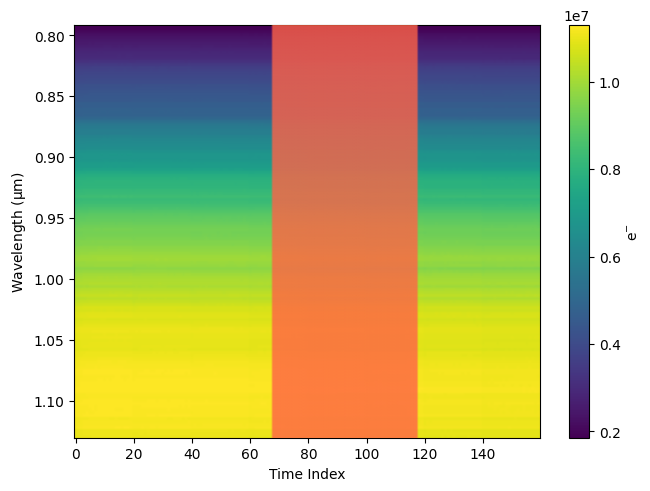

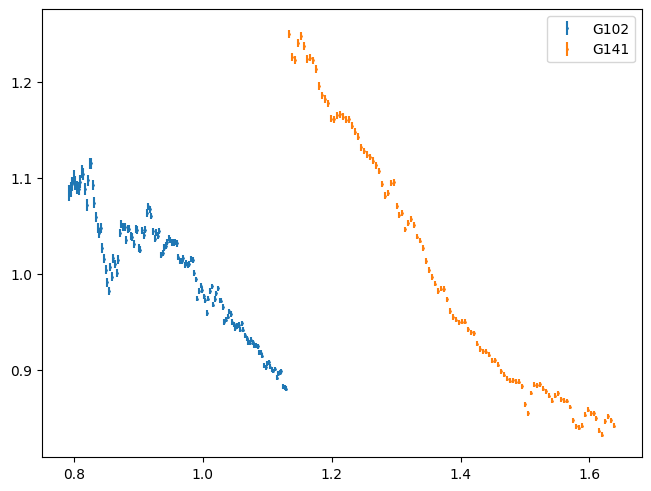

<Figure size 640x480 with 0 Axes>

In [ ]:
visit = 'S22'
err_factor = S22_SED_err_factor

'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow

# 'Adjust uncertainties and bin the rainbow'
# for i in range(len(rainbow.wavelength.value)):
#     speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] #* err_factor[i]

'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )

out_of_transit.imshow()
'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = oot_spec_err * calibrated_mean_spec

# Convert to JAX arrays
calibrated_mean_spec_G102 = jnp.array(calibrated_mean_spec)
oot_spec_err_G102 = jnp.array(oot_spec_err)
SED_wavelengths_G102 = jnp.array(_SED_wavelengths)

######## NOW DO THAT FOR F21 ##############
visit = 'F21'
err_factor = F21_SED_err_factor

'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow

# 'Adjust uncertainties and bin the rainbow'
# for i in range(len(rainbow.wavelength.value)):
#     speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] #* err_factor[i]

'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )

'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
_oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = _oot_spec_err * calibrated_mean_spec

# Convert to JAX arrays
calibrated_mean_spec_G141 = jnp.array(calibrated_mean_spec)
oot_spec_err_G141 = jnp.array(oot_spec_err)
SED_wavelengths_G141 = jnp.array(_SED_wavelengths)

plt.figure()
plt.errorbar(SED_wavelengths_G102,calibrated_mean_spec_G102,yerr=oot_spec_err_G102*100,fmt='o',label='G102',ms=1)
plt.errorbar(SED_wavelengths_G141,calibrated_mean_spec_G141,yerr=oot_spec_err_G141*100,fmt='o',label='G141',ms=1)
plt.legend()
plt.show()
plt.clf()

## Define the Numpyro Model

In [ ]:
def numpyro_model(N_temps=2, return_max_likelihood=False):
    """
    Define the probabilistic model in NUMPYRO with N_temps components.
    
    Args:
        N_temps: Number of temperature components (1, 2, 3, or 4)
        return_max_likelihood: If True, also return the maximum log likelihood value
    """
    # This function is the actual model that NumPyro will call
    def model():
        # Temperature parameters - T1 now in higher range (3700-4500)
        temp_bounds = [
            (3700, 4000),   # T1 bounds (higher temperature)
            (3000, 3700),   # T2 bounds (cooler component)
            (2000, 3200),   # T3 bounds 
        ]
        ff_bounds = [
            (0, 0),   # T1 bounds (higher temperature)
            (-3, 1),   # T2 bounds (cooler component)
            (-3, 1),   # T3 bounds 
        ]
        
        # Sample temperatures
        T_samples = []
        for i in range(1, N_temps + 1):
            if i == 2:
                delta_T2 = numpyro.sample('delta_T2', dist.Uniform(-1000,0))
                T = numpyro.deterministic(f'T{i}', T_samples[0] + delta_T2)
            elif i == 3:
                delta_T3 = numpyro.sample('delta_T3', dist.Uniform(-1700,200))
                T = numpyro.deterministic(f'T{i}', T_samples[0] + delta_T3)
            else:
                T = numpyro.sample(f'T{i}', dist.Uniform(*temp_bounds[i-1]))
                
            T_samples.append(T)
        
        # Sample scale factors for components 2..N
        ff_samples = [1.0]  # First component always has f=1
        for i in range(2, N_temps + 1):
            ff = 10**numpyro.sample(f'ff{i}', dist.Uniform(*ff_bounds[i-1]))
            ff_samples.append(ff)

        # NEW: Sample metallicity and C/O ratio
        metallicity = numpyro.sample('metallicity', dist.Uniform(-1.0, 1.0))
        cto_ratio = numpyro.sample('cto_ratio', dist.Uniform(0.3, 0.9))
        log_g = 4.52 #numpyro.sample('log_g', dist.Uniform(4.0, 5.0))

        # Other parameters
        offset_G102 = numpyro.sample('offset_G102', dist.Uniform(0.2, 0.8))
        slope_G141 = numpyro.sample('slope_G141', dist.Uniform(-0.6, 0.6))
        slope_G102 = numpyro.sample('slope_G102', dist.Uniform(-0.6, 0.6))
        sigma_conv = 0.5  #numpyro.sample('sigma_conv', dist.Uniform(0.1, 8))
        beta_102 = numpyro.sample('beta_G102', dist.Uniform(2.0, 2.7))
        beta_141 = numpyro.sample('beta_G141', dist.Uniform(2.0, 2.5))

        # Adjust and concatenate data with slopes applied
        offset_102 = jnp.asarray(offset_G102, dtype=jnp.float64)
        spec_G102_with_offset = jnp.array(calibrated_mean_spec_G102 + offset_102)

        spec_G102_with_slope = spec_G102_with_offset + slope_G102 * (SED_wavelengths_G102 - SED_wavelengths_G102[0])
        spec_G141_with_slope = jnp.array(calibrated_mean_spec_G141) + slope_G141 * (SED_wavelengths_G141 - SED_wavelengths_G141[0])
        
        # Concatenate the spectra
        _spec_flux_jax = jnp.concatenate([spec_G102_with_slope, spec_G141_with_slope])
        spec_flux_jax = _spec_flux_jax / jnp.mean(_spec_flux_jax)
        spec_err_jax = jnp.concatenate(
            [
                jnp.array((10**beta_102) * oot_spec_err_G102),
                jnp.array((10**beta_141) * oot_spec_err_G141)
            ]
        )
        combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102), 
                                                    jnp.array(SED_wavelengths_G141)])
        
        @jit
        def decomp_model(temps, scales, log_g, metal, cto, sigma):
            # Get spectra for all temperatures with variable metallicity and C/O
            spectra = [get_sphinx_spectrum_jax(T=Temp, logg=log_g, metallicity=metal, CtoO=cto) for Temp in temps]
            
            # Calculate combined spectrum with scaling factors
            flux_combined = scales[0] * spectra[0][1]  # Start with first component
            for i in range(1, N_temps):
                flux_combined += scales[i] * spectra[i][1]
            
            # Normalize
            _model_flux = flux_combined / jnp.mean(flux_combined)
            
            # Convolve and bin
            convolved = convolve_spectrum_jax(
                panchromatic_wavelengths, 
                _model_flux, 
                sigma=jnp.asarray(sigma, dtype=jnp.float64)
            )
            binned_model_flux = shone.bin_spectrum(
                combined_SED_wavelengths, 
                panchromatic_wavelengths, 
                convolved
            )
            model_flux = binned_model_flux / jnp.mean(binned_model_flux)
            
            return model_flux

        # Calculate model flux with metallicity and C/O
        model_flux = decomp_model(T_samples, ff_samples, log_g, metallicity, cto_ratio, sigma_conv)
        
        # Define the likelihood
        log_likelihood = dist.Normal(model_flux, spec_err_jax).log_prob(spec_flux_jax).sum()
        
        # Sample the observed data
        numpyro.sample("Obs", dist.Normal(model_flux, spec_err_jax), obs=spec_flux_jax)
        
        # Track log likelihood for maximum likelihood calculation
        if return_max_likelihood:
            numpyro.deterministic('log_likelihood', log_likelihood)
    
    # If we want to return the max likelihood callback
    if return_max_likelihood:
        def get_max_likelihood(samples):
            """Extract maximum log likelihood from samples"""
            log_lik_samples = samples.get('log_likelihood', None)
            if log_lik_samples is not None:
                return float(jnp.max(log_lik_samples))
            return None
        
        return model, get_max_likelihood
    else:
        return model

## Run 2T Model

In [ ]:
n_temps = 2
n_warmup = 1_000
n_samples = 2_000
n_chains = 12
n_check = 2

# Get the model function and callback
model_func, get_max_likelihood = numpyro_model(N_temps=n_temps, return_max_likelihood=True)

model_designation = f'jointvisit_{n_temps}T_{n_samples}_{n_chains}chains_SED_sphinx'

rng_key = PRNGKey(22)
# rng_keys = random.split(rng_key, n_chains)

sampler = NUTS(
    model_func,  # Use the returned function
    dense_mass=False
)

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=n_check, on_checkpoint=post_batch_viz_save)

  0%|          | 0/3 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

### Post-Inference Analysis

In [ ]:
mcmc.print_summary()

# Extract maximum likelihood after sampling
if get_max_likelihood is not None:
    samples = mcmc.get_samples()
    max_log_lik = get_max_likelihood(samples)
    print(f"Maximum log likelihood: {max_log_lik:.6f}")

result = arviz.from_numpyro(mcmc)

In [ ]:
'Save the result'
result.to_netcdf(f'../../data/samples/{model_designation}')

'Print the summary'
arviz.summary(result)

In [ ]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

In [ ]:
'Extract median result'
median_params = arviz.summary(result,stat_focus='median')['median']

In [ ]:
'Make a corner plot'
corner.corner(
    result, 
    # var_names=['~offset_G102',
    #                    r'~$\beta_{\rm G102}$',
    #                    r'~$\beta_{\rm G141}$',
    #                    r'~$\sigma_{\rm conv}$'],
    # quiet=True,
)
plt.savefig(f'../../figs/{model_designation}_corner.png',dpi=400)

In [ ]:
samples = mcmc.get_samples()

max_likelihood_idx = jnp.argmax(samples['log_likelihood'])

#Extract the maximum likelihood parameters
max_likelihood_params = {}
for key in samples.keys():
    max_likelihood_params[key] = samples[key][max_likelihood_idx]

#Select 200 samples for plotting
n_random_samples = 200
n_total_samples = len(samples['log_likelihood'])
random_indices = np.random.choice(n_total_samples, size=min(n_random_samples, n_total_samples), replace=False)
def compute_model_flux(params):
    temps = []
    for i in range(1, n_temps + 1):
        temp_key = f'T{i}'
        temps.append(jnp.asarray(params[temp_key], dtype=jnp.float64))
    metallicity = jnp.asarray(params['metallicity'], dtype=jnp.float64)
    log_g = 4.52 #jnp.asarray(params['log_g'], dtype=jnp.float64)
    cto_ratio = jnp.asarray(params['cto_ratio'], dtype=jnp.float64)
    spectra = [get_sphinx_spectrum_jax(T=Temp, logg=log_g, metallicity=metallicity, CtoO=cto_ratio) for Temp in temps]
    scales = [1.0]
    for i in range(2, n_temps + 1):
        ff_key = f'ff{i}'
        scale = jnp.asarray(10**params[ff_key], dtype=jnp.float64)
        scales.append(scale)
    
    # Calculate combined spectrum
    _flux = scales[0] * spectra[0][1]
    for i in range(1, n_temps):
        _flux += scales[i] * spectra[i][1]
    
    _model_flux = _flux / jnp.mean(_flux)
    convolved = convolve_spectrum_jax(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
    binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, convolved)
    return binned_model_flux / jnp.mean(binned_model_flux)

# CALCULATE FILLING FACTORS FOR ALL SAMPLES
n_samples = len(samples['log_likelihood'])
all_filling_factors = np.zeros((n_samples, n_temps))
for idx in range(n_samples):
    sample_scales = [1.0]  # First component scale is always 1.0 (10^0)
    for i in range(2, n_temps + 1):
        ff_key = f'ff{i}'
        scale = 10**samples[ff_key][idx]  # Convert from log10 to linear
        sample_scales.append(scale)
    total_scale = sum(sample_scales)
    all_filling_factors[idx, :] = [scale / total_scale for scale in sample_scales]

# Calculate statistics for filling factors
ff_medians = np.median(all_filling_factors, axis=0)
ff_percentiles = np.percentile(all_filling_factors, [16, 84], axis=0)  # 1-sigma equivalent
ff_means = np.mean(all_filling_factors, axis=0)
ff_stds = np.std(all_filling_factors, axis=0)

# Print filling factor statistics
print("\n" + "="*60)
print("FILLING FACTORS FOR EACH COMPONENT (from full posterior)")
print("="*60)
for i in range(n_temps):
    print(f"Component {i+1}:")
    print(f"  Median = {ff_medians[i]:.4f} ({ff_medians[i]*100:.2f}%)")
    print(f"  Mean ± Std = {ff_means[i]:.4f} ± {ff_stds[i]:.4f}")
    print(f"  16th-84th percentile = [{ff_percentiles[0,i]:.4f}, {ff_percentiles[1,i]:.4f}]")
    print(f"  Range = [{np.min(all_filling_factors[:,i]):.4f}, {np.max(all_filling_factors[:,i]):.4f}]")
print(f"\nSum of median filling factors: {np.sum(ff_medians):.4f}")
print("="*60 + "\n")

# Optional: Plot filling factor distributions
fig_ff, axes_ff = plt.subplots(1, n_temps, figsize=(4*n_temps, 4))
if n_temps == 1:
    axes_ff = [axes_ff]

for i in range(n_temps):
    axes_ff[i].hist(all_filling_factors[:, i], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes_ff[i].axvline(ff_medians[i], color='red', linestyle='--', label=f'Median: {ff_medians[i]:.3f}')
    axes_ff[i].axvline(ff_percentiles[0, i], color='orange', linestyle=':', label='16th/84th')
    axes_ff[i].axvline(ff_percentiles[1, i], color='orange', linestyle=':')
    axes_ff[i].set_xlabel(f'Filling Factor - Comp {i+1}')
    axes_ff[i].set_ylabel('Frequency')
    axes_ff[i].legend(fontsize=8)
    axes_ff[i].set_title(f'T{temps[i] if 'temps' in locals() else i+1:.0f}K' if 'temps' in locals() else f'Component {i+1}')

plt.suptitle('Filling Factor Distributions')
plt.tight_layout()
plt.savefig(f'../../figs/{model_designation}_filling_factor_distributions.png', dpi=200)

# ====================================================================
# NOW USE MAX LIKELIHOOD FOR PLOTTING THE SPECTRUM
spec_G102 = jnp.array(calibrated_mean_spec_G102 + jnp.asarray(max_likelihood_params['offset_G102'], dtype=jnp.float64))
spec_G141 = jnp.array(calibrated_mean_spec_G141)

_spec_flux_jax = jnp.concatenate([
    spec_G102 + max_likelihood_params['slope_G102'] * (SED_wavelengths_G102 - SED_wavelengths_G102[0]),
    spec_G141 + max_likelihood_params['slope_G141'] * (SED_wavelengths_G141 - SED_wavelengths_G141[0]) 
])

max_likelihood_spec_flux = _spec_flux_jax / jnp.mean(_spec_flux_jax)
max_likelihood_spec_err = jnp.concatenate([
    jnp.array(oot_spec_err_G102 * jnp.asarray(10**max_likelihood_params['beta_G102'], dtype=jnp.float64)),
    jnp.array(oot_spec_err_G141 * jnp.asarray(10**max_likelihood_params['beta_G141'], dtype=jnp.float64))
])
combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102), jnp.array(SED_wavelengths_G141)])

filter_sigma = 0.5  #max_likelihood_params['sigma_conv']

temps = []
for i in range(1, n_temps + 1):
    temp_key = f'T{i}'
    temps.append(jnp.asarray(max_likelihood_params[temp_key], dtype=jnp.float64))

# After extracting temps, also extract metallicity and CtoO
metallicity = jnp.asarray(max_likelihood_params['metallicity'], dtype=jnp.float64)
log_g = 4.52 #jnp.asarray(max_likelihood_params['log_g'], dtype=jnp.float64)
cto_ratio = jnp.asarray(max_likelihood_params['cto_ratio'], dtype=jnp.float64)

# Get spectra for all temperature components
spectra = [get_sphinx_spectrum_jax(T=Temp, logg=log_g, metallicity=metallicity, CtoO=cto_ratio) for Temp in temps]

# Get scale factors for max likelihood
scales = [1.0]
ff_values = []  # Store ff values for filling factor calculation
for i in range(2, n_temps + 1):
    ff_key = f'ff{i}'
    scale = jnp.asarray(10**max_likelihood_params[ff_key], dtype=jnp.float64)
    scales.append(scale)
    ff_values.append(scale)

# Calculate max likelihood filling factors (for reference)
all_scales = [1.0] + ff_values
total_scale = sum(all_scales)
ml_filling_factors = [scale / total_scale for scale in all_scales]

print("\nMaximum Likelihood Filling Factors (for comparison):")
for i, ff in enumerate(ml_filling_factors, 1):
    print(f"  Component {i}: {ff:.4f} ({ff*100:.2f}%)")

# Calculate individual component fluxes for plotting
component_fluxes = []
_max_likelihood_flux = scales[0] * spectra[0][1]
for i in range(1, n_temps):
    _max_likelihood_flux += scales[i] * spectra[i][1]

for i in range(n_temps):
    # Calculate individual component flux (normalized and convolved)
    comp_flux = scales[i] * spectra[i][1]
    comp_flux_norm = comp_flux / jnp.mean(_max_likelihood_flux)  # Normalize by total mean flux
    comp_convolved = convolve_spectrum_jax(panchromatic_wavelengths, comp_flux_norm, sigma=filter_sigma)
    comp_binned = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, comp_convolved)
    component_fluxes.append(comp_binned / jnp.mean(comp_binned))  # Final normalization

# Calculate combined spectrum
_model_flux = _max_likelihood_flux / jnp.mean(_max_likelihood_flux)
convolved = convolve_spectrum_jax(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, convolved)
max_likelihood_model_flux = (binned_model_flux / jnp.mean(binned_model_flux))

# Plot with maximum likelihood parameters
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(r'0.8-1.64 $\mu$m SED with ' + f'{n_temps}T Model (Maximum Likelihood)', fontsize=20)
axs[1].set_title('Residuals', fontsize=14)
axs[1].set_xlim(0.805, 1.645)
axs[1].set_ylim(-4, 4)
axs[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=14)
axs[0].set_ylabel('Relative Flux', fontsize=14)
axs[1].set_ylabel(r'$\sigma$', fontsize=14)

# Plot 200 random samples in red with low alpha
print(f"Plotting {len(random_indices)} random posterior samples...")
for idx in random_indices:
    # Extract parameters for this random sample
    random_params = {}
    for key in samples.keys():
        random_params[key] = samples[key][idx]
    
    # Compute model flux for this random sample
    random_model_flux = compute_model_flux(random_params)
    
    # Plot in red with low alpha
    axs[0].plot(combined_SED_wavelengths, random_model_flux, 
                color='red', alpha=0.05, linewidth=0.5, zorder=50)

# Plot individual components with filling factor uncertainties in legend
colors = ['green', 'purple', 'cyan'][:n_temps]
for i in range(n_temps):
    # Create label with median and uncertainty
    label = f'T{temps[i]:.0f}K: ff = {ff_medians[i]:.3f} ± {ff_stds[i]:.3f}'
    axs[0].plot(combined_SED_wavelengths, component_fluxes[i], 
                color=colors[i], linewidth=2, linestyle='--', 
                label=label, zorder=100,alpha=0.5)

axs[0].errorbar(combined_SED_wavelengths,
                max_likelihood_spec_flux,
                yerr=max_likelihood_spec_err,
                fmt='o', color='b', ms=1, alpha=0.7, zorder=150, label='Data')
axs[0].plot(combined_SED_wavelengths,
            max_likelihood_model_flux, color='k', linewidth=2, zorder=200, label='Total Model')

axs[0].legend(loc='upper right', fontsize=10)

axs[1].scatter(combined_SED_wavelengths,
               (max_likelihood_model_flux - max_likelihood_spec_flux) / max_likelihood_spec_err,
               color='gray', zorder=150)
axs[1].axhline(0, color='k', zorder=-100)

plt.tight_layout()
plt.savefig(f'../../figs/{model_designation}_max_likelihood_result.png', dpi=200)

## Run 3T Model

In [ ]:
n_temps = 3
n_warmup = 1_000
n_samples = 2_000
n_chains = 12
n_check = 2

# Get the model function and callback
model_func, get_max_likelihood = numpyro_model(N_temps=n_temps, return_max_likelihood=True)

model_designation = f'jointvisit_{n_temps}T_{n_samples}_{n_chains}chains_SED_sphinx'

rng_key = PRNGKey(42)
# rng_keys = random.split(rng_key, n_chains)

sampler = NUTS(
    model_func,  # Use the returned function
    dense_mass=True
)

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=n_check, on_checkpoint=post_batch_viz_save)

In [ ]:
mcmc.print_summary()

# Extract maximum likelihood after sampling
if get_max_likelihood is not None:
    samples = mcmc.get_samples()
    max_log_lik = get_max_likelihood(samples)
    print(f"Maximum log likelihood: {max_log_lik:.6f}")

result = arviz.from_numpyro(mcmc)

'Save the result'
result.to_netcdf(f'../../data/samples/{model_designation}')

'Print the summary'
arviz.summary(result)

'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

In [ ]:
'Make a corner plot'
corner.corner(
    result, 
    # var_names=['~offset_G102',
    #                    r'~$\beta_{\rm G102}$',
    #                    r'~$\beta_{\rm G141}$',
    #                    r'~$\sigma_{\rm conv}$'],
    # quiet=True,
)
plt.savefig(f'../../figs/{model_designation}_corner.png',dpi=400)

In [ ]:
samples = mcmc.get_samples()

max_likelihood_idx = jnp.argmax(samples['log_likelihood'])

#Extract the maximum likelihood parameters
max_likelihood_params = {}
for key in samples.keys():
    max_likelihood_params[key] = samples[key][max_likelihood_idx]

#Select 200 samples for plotting
n_random_samples = 200
n_total_samples = len(samples['log_likelihood'])
random_indices = np.random.choice(n_total_samples, size=min(n_random_samples, n_total_samples), replace=False)
def compute_model_flux(params):
    temps = []
    for i in range(1, n_temps + 1):
        temp_key = f'T{i}'
        temps.append(jnp.asarray(params[temp_key], dtype=jnp.float64))
    metallicity = jnp.asarray(params['metallicity'], dtype=jnp.float64)
    log_g = 4.52 #jnp.asarray(params['log_g'], dtype=jnp.float64)
    cto_ratio = jnp.asarray(params['cto_ratio'], dtype=jnp.float64)
    spectra = [get_sphinx_spectrum_jax(T=Temp, logg=log_g, metallicity=metallicity, CtoO=cto_ratio) for Temp in temps]
    scales = [1.0]
    for i in range(2, n_temps + 1):
        ff_key = f'ff{i}'
        scale = jnp.asarray(10**params[ff_key], dtype=jnp.float64)
        scales.append(scale)
    
    # Calculate combined spectrum
    _flux = scales[0] * spectra[0][1]
    for i in range(1, n_temps):
        _flux += scales[i] * spectra[i][1]
    
    _model_flux = _flux / jnp.mean(_flux)
    convolved = convolve_spectrum_jax(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
    binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, convolved)
    return binned_model_flux / jnp.mean(binned_model_flux)

# CALCULATE FILLING FACTORS FOR ALL SAMPLES
n_samples = len(samples['log_likelihood'])
all_filling_factors = np.zeros((n_samples, n_temps))
for idx in range(n_samples):
    sample_scales = [1.0]  # First component scale is always 1.0 (10^0)
    for i in range(2, n_temps + 1):
        ff_key = f'ff{i}'
        scale = 10**samples[ff_key][idx]  # Convert from log10 to linear
        sample_scales.append(scale)
    total_scale = sum(sample_scales)
    all_filling_factors[idx, :] = [scale / total_scale for scale in sample_scales]

# Calculate statistics for filling factors
ff_medians = np.median(all_filling_factors, axis=0)
ff_percentiles = np.percentile(all_filling_factors, [16, 84], axis=0)  # 1-sigma equivalent
ff_means = np.mean(all_filling_factors, axis=0)
ff_stds = np.std(all_filling_factors, axis=0)

# Print filling factor statistics
print("\n" + "="*60)
print("FILLING FACTORS FOR EACH COMPONENT (from full posterior)")
print("="*60)
for i in range(n_temps):
    print(f"Component {i+1}:")
    print(f"  Median = {ff_medians[i]:.4f} ({ff_medians[i]*100:.2f}%)")
    print(f"  Mean ± Std = {ff_means[i]:.4f} ± {ff_stds[i]:.4f}")
    print(f"  16th-84th percentile = [{ff_percentiles[0,i]:.4f}, {ff_percentiles[1,i]:.4f}]")
    print(f"  Range = [{np.min(all_filling_factors[:,i]):.4f}, {np.max(all_filling_factors[:,i]):.4f}]")
print(f"\nSum of median filling factors: {np.sum(ff_medians):.4f}")
print("="*60 + "\n")

# Optional: Plot filling factor distributions
fig_ff, axes_ff = plt.subplots(1, n_temps, figsize=(4*n_temps, 4))
if n_temps == 1:
    axes_ff = [axes_ff]

for i in range(n_temps):
    axes_ff[i].hist(all_filling_factors[:, i], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes_ff[i].axvline(ff_medians[i], color='red', linestyle='--', label=f'Median: {ff_medians[i]:.3f}')
    axes_ff[i].axvline(ff_percentiles[0, i], color='orange', linestyle=':', label='16th/84th')
    axes_ff[i].axvline(ff_percentiles[1, i], color='orange', linestyle=':')
    axes_ff[i].set_xlabel(f'Filling Factor - Comp {i+1}')
    axes_ff[i].set_ylabel('Frequency')
    axes_ff[i].legend(fontsize=8)
    axes_ff[i].set_title(f'T{temps[i] if 'temps' in locals() else i+1:.0f}K' if 'temps' in locals() else f'Component {i+1}')

plt.suptitle('Filling Factor Distributions')
plt.tight_layout()
plt.savefig(f'../../figs/{model_designation}_filling_factor_distributions.png', dpi=200)

# ====================================================================
# NOW USE MAX LIKELIHOOD FOR PLOTTING THE SPECTRUM
spec_G102 = jnp.array(calibrated_mean_spec_G102 + jnp.asarray(max_likelihood_params['offset_G102'], dtype=jnp.float64))
spec_G141 = jnp.array(calibrated_mean_spec_G141)

_spec_flux_jax = jnp.concatenate([
    spec_G102 + max_likelihood_params['slope_G102'] * (SED_wavelengths_G102 - SED_wavelengths_G102[0]),
    spec_G141 + max_likelihood_params['slope_G141'] * (SED_wavelengths_G141 - SED_wavelengths_G141[0]) 
])

max_likelihood_spec_flux = _spec_flux_jax / jnp.mean(_spec_flux_jax)
max_likelihood_spec_err = jnp.concatenate([
    jnp.array(oot_spec_err_G102 * jnp.asarray(10**max_likelihood_params['beta_G102'], dtype=jnp.float64)),
    jnp.array(oot_spec_err_G141 * jnp.asarray(10**max_likelihood_params['beta_G141'], dtype=jnp.float64))
])
combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102), jnp.array(SED_wavelengths_G141)])

filter_sigma = 0.5  #max_likelihood_params['sigma_conv']

temps = []
for i in range(1, n_temps + 1):
    temp_key = f'T{i}'
    temps.append(jnp.asarray(max_likelihood_params[temp_key], dtype=jnp.float64))

# After extracting temps, also extract metallicity and CtoO
metallicity = jnp.asarray(max_likelihood_params['metallicity'], dtype=jnp.float64)
log_g = 4.52 #jnp.asarray(max_likelihood_params['log_g'], dtype=jnp.float64)
cto_ratio = jnp.asarray(max_likelihood_params['cto_ratio'], dtype=jnp.float64)

# Get spectra for all temperature components
spectra = [get_sphinx_spectrum_jax(T=Temp, logg=log_g, metallicity=metallicity, CtoO=cto_ratio) for Temp in temps]

# Get scale factors for max likelihood
scales = [1.0]
ff_values = []  # Store ff values for filling factor calculation
for i in range(2, n_temps + 1):
    ff_key = f'ff{i}'
    scale = jnp.asarray(10**max_likelihood_params[ff_key], dtype=jnp.float64)
    scales.append(scale)
    ff_values.append(scale)

# Calculate max likelihood filling factors (for reference)
all_scales = [1.0] + ff_values
total_scale = sum(all_scales)
ml_filling_factors = [scale / total_scale for scale in all_scales]

print("\nMaximum Likelihood Filling Factors (for comparison):")
for i, ff in enumerate(ml_filling_factors, 1):
    print(f"  Component {i}: {ff:.4f} ({ff*100:.2f}%)")

# Calculate individual component fluxes for plotting
component_fluxes = []
_max_likelihood_flux = scales[0] * spectra[0][1]
for i in range(1, n_temps):
    _max_likelihood_flux += scales[i] * spectra[i][1]

for i in range(n_temps):
    # Calculate individual component flux (normalized and convolved)
    comp_flux = scales[i] * spectra[i][1]
    comp_flux_norm = comp_flux / jnp.mean(_max_likelihood_flux)  # Normalize by total mean flux
    comp_convolved = convolve_spectrum_jax(panchromatic_wavelengths, comp_flux_norm, sigma=filter_sigma)
    comp_binned = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, comp_convolved)
    component_fluxes.append(comp_binned / jnp.mean(comp_binned))  # Final normalization

# Calculate combined spectrum
_model_flux = _max_likelihood_flux / jnp.mean(_max_likelihood_flux)
convolved = convolve_spectrum_jax(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, convolved)
max_likelihood_model_flux = (binned_model_flux / jnp.mean(binned_model_flux))

# Plot with maximum likelihood parameters
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(r'0.8-1.64 $\mu$m SED with ' + f'{n_temps}T Model (Maximum Likelihood)', fontsize=20)
axs[1].set_title('Residuals', fontsize=14)
axs[1].set_xlim(0.805, 1.645)
axs[1].set_ylim(-4, 4)
axs[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=14)
axs[0].set_ylabel('Relative Flux', fontsize=14)
axs[1].set_ylabel(r'$\sigma$', fontsize=14)

# Plot 200 random samples in red with low alpha
print(f"Plotting {len(random_indices)} random posterior samples...")
for idx in random_indices:
    # Extract parameters for this random sample
    random_params = {}
    for key in samples.keys():
        random_params[key] = samples[key][idx]
    
    # Compute model flux for this random sample
    random_model_flux = compute_model_flux(random_params)
    
    # Plot in red with low alpha
    axs[0].plot(combined_SED_wavelengths, random_model_flux, 
                color='red', alpha=0.05, linewidth=0.5, zorder=50)

# Plot individual components with filling factor uncertainties in legend
colors = ['green', 'purple', 'cyan'][:n_temps]
for i in range(n_temps):
    # Create label with median and uncertainty
    label = f'T{temps[i]:.0f}K: ff = {ff_medians[i]:.3f} ± {ff_stds[i]:.3f}'
    axs[0].plot(combined_SED_wavelengths, component_fluxes[i], 
                color=colors[i], linewidth=2, linestyle='--', 
                label=label, zorder=100, alpha=0.5)

axs[0].errorbar(combined_SED_wavelengths,
                max_likelihood_spec_flux,
                yerr=max_likelihood_spec_err,
                fmt='o', color='b', ms=1, alpha=0.7, zorder=150, label='Data')
axs[0].plot(combined_SED_wavelengths,
            max_likelihood_model_flux, color='k', linewidth=2, zorder=200, label='Total Model')

axs[0].legend(loc='upper right', fontsize=10)

axs[1].scatter(combined_SED_wavelengths,
               (max_likelihood_model_flux - max_likelihood_spec_flux) / max_likelihood_spec_err,
               color='gray', zorder=150)
axs[1].axhline(0, color='k', zorder=-100)

plt.tight_layout()
plt.savefig(f'../../figs/{model_designation}_max_likelihood_result.png', dpi=200)

# Compare multiple models of the same dataset

In [ ]:
# compare_dict = {}

# compare_dict['model_1'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_3T_1000_11chains_SED_separatebetas')
# compare_dict['model_2'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_3T_1000_14chains_SED_photonerrs')
# # compare_dict['model_3'] = arviz.InferenceData.from_netcdf('../../data/samples/')

# arviz.compare(compare_dict)

From https://num.pyro.ai/en/latest/tutorials/bad_posterior_geometry.html

In general it is difficult to assess whether the samples returned from HMC or NUTS represent accurate (approximate) samples from the posterior. Two general rules of thumb, however, are to look at the effective sample size (ESS) and r_hat diagnostics returned by mcmc.print_summary(). If we see values of r_hat in the range (1.0, 1.05) and effective sample sizes that are comparable to the total number of samples num_samples (assuming thinning=1) then we have good reason to believe that HMC is doing a good job. If, however, we see low effective sample sizes or large r_hats for some of the variables (e.g. r_hat = 1.15) then HMC is likely struggling with the posterior geometry. In the following we will use r_hat as our primary diagnostic metric.